In [13]:
%pip install keras_tuner 


  Using cached keras_tuner-1.4.8-py3-none-any.whl.metadata (5.6 kB)
  Using cached kt_legacy-1.0.5-py3-none-any.whl.metadata (221 bytes)
Using cached keras_tuner-1.4.8-py3-none-any.whl (129 kB)
Using cached kt_legacy-1.0.5-py3-none-any.whl (9.6 kB)

   ---------------------------------------- 0/2 [kt-legacy]
   ---------------------------------------- 0/2 [kt-legacy]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------------------- ------------------- 1/2 [keras_tuner]
   -------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step 1: Import Libraries and Load Data
## First, we set up our environment and load the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample



In [3]:
# Load the data
df = pd.read_csv('dataset/respiratory symptoms and treatment.csv')

# Initial inspection
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 18069 entries, 0 to 18068
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Symptoms    17925 non-null  str    
 1   Age         17995 non-null  float64
 2   Sex         17563 non-null  str    
 3   Disease     18069 non-null  str    
 4   Treatment   17317 non-null  str    
 5   Nature      17227 non-null  str    
 6   Unnamed: 6  0 non-null      float64
 7   Unnamed: 7  0 non-null      float64
 8   Unnamed: 8  0 non-null      float64
dtypes: float64(4), str(5)
memory usage: 1.2 MB
None
                     Symptoms  Age     Sex Disease    Treatment Nature  \
0                   coughing   5.0  female  Asthma   Omalizumab   high   
1  tight feeling in the chest  4.0  female  Asthma  Mepolizumab   high   
2                    wheezing  6.0    male  Asthma  Mepolizumab   high   
3         shortness of breath  7.0    male  Asthma  Mepolizumab   high   
4         shortness of breath

In [4]:
df.head()

,Symptoms,Age,Sex,Disease,Treatment,Nature,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,coughing,5.0,female,Asthma,Omalizumab,high,NaN,NaN,NaN
1,tight feeling in the chest,4.0,female,Asthma,Mepolizumab,high,NaN,NaN,NaN
2,wheezing,6.0,male,Asthma,Mepolizumab,high,NaN,NaN,NaN
3,shortness of breath,7.0,male,Asthma,Mepolizumab,high,NaN,NaN,NaN
4,shortness of breath,9.0,male,Asthma,Mepolizumab,high,NaN,NaN,NaN


# Step 2: Data Cleaning
## In this step, we remove redundant columns and fix formatting issues (like extra spaces in text).

In [6]:
# 1. Drop completely empty unnamed columns
df.drop(columns=['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8','Treatment','Nature'], inplace=True, errors='ignore')

# 2. Strip whitespace from all string columns (crucial for matching categories)
str_cols = df.select_dtypes(include=['object']).columns
for col in str_cols:
    df[col] = df[col].str.strip()

# 3. Handle Missing Values
# Impute Age with median (more robust to outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Impute categorical columns with the Mode (most frequent value)
for col in ['Symptoms', 'Sex']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


C:\Users\zulqa\AppData\Local\Temp\ipykernel_9636\2386049885.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include=['object']).columns


In [8]:
len(df['Symptoms'].value_counts())

31

# Step 3: Exploratory Data Analysis (EDA)
## Visualizing the data helps understand distributions and class imbalances.

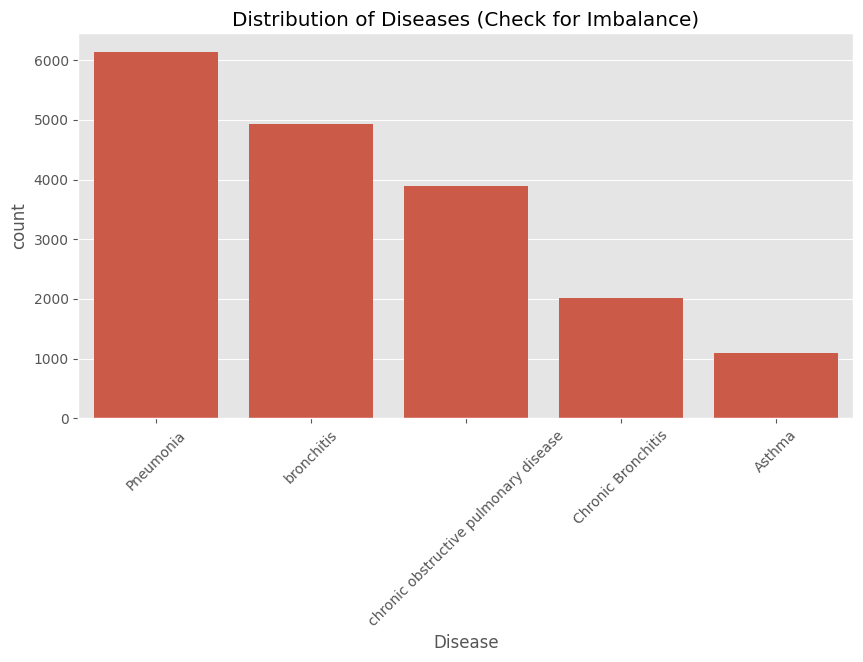

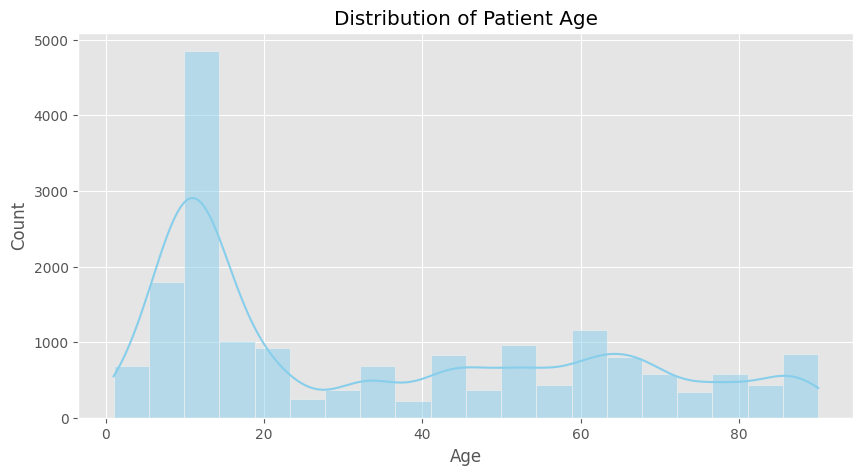

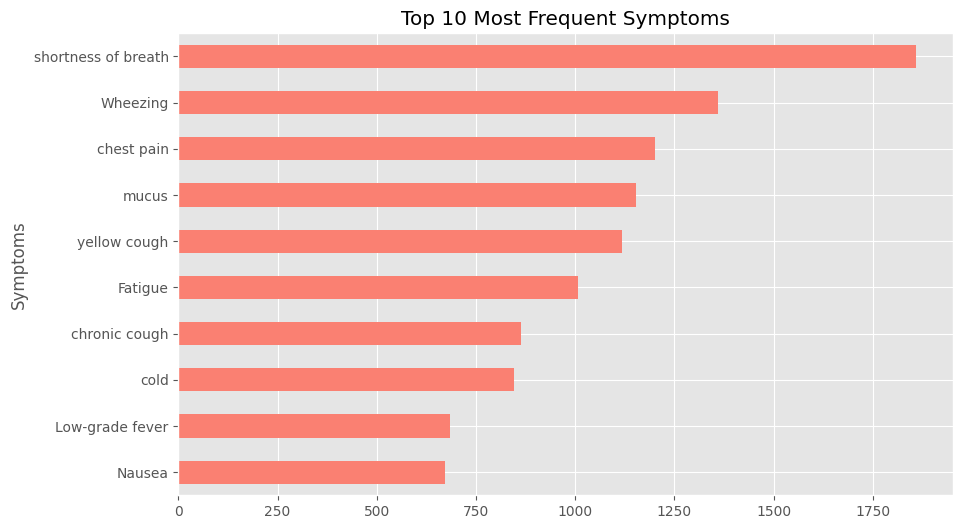

In [ ]:
plt.style.use('ggplot')

# 1. Distribution of the Target (Disease)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Disease', order=df['Disease'].value_counts().index)
plt.title('Distribution of Diseases (Check for Imbalance)')
plt.xticks(rotation=45)
plt.show()

# 2. Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue') # type: ignore
plt.title('Distribution of Patient Age')
plt.show()

# 3. Symptoms Analysis
plt.figure(figsize=(10, 6))
df['Symptoms'].value_counts().nlargest(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Most Frequent Symptoms')
plt.gca().invert_yaxis()
plt.show()

# Step 4: Data Preprocessing (Scaling & Encoding)
## Machine learning models require numerical data. We scale numerical features and encode categorical ones.

In [11]:
# Create a copy for modeling
df_model = df.copy()

# 1. Scale Numerical Features (Age)
scaler = StandardScaler()
df_model['Age'] = scaler.fit_transform(df_model[['Age']])

# 2. Encode Categorical Features (One-Hot Encoding)
# This converts categories into binary columns (0 and 1)
categorical_features = ['Symptoms', 'Sex']
df_final = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

# 3. Encode the Target Variable (Disease)
le = LabelEncoder()
df_final['Disease'] = le.fit_transform(df_final['Disease'])

# Save mapping for production use
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Disease Mapping:", mapping)

Disease Mapping: {'Asthma': 0, 'Chronic Bronchitis': 1, 'Pneumonia': 2, 'bronchitis': 3, 'chronic obstructive pulmonary disease': 4}


# Step 5: Train-Test Split and Handling Imbalance
## Since your data is imbalanced (e.g., Asthma is much less frequent than Pneumonia), we use oversampling on the training set to ensure the model learns all classes equally.

In [12]:
# 1. Split features (X) and target (y)
X = df_final.drop('Disease', axis=1)
y = df_final['Disease']

# 2. Initial Train-Test Split (80/20)
# We use 'stratify' to keep the original distribution in the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Handle Imbalance (Oversampling the minority classes in Training set)
train_df = pd.concat([X_train, y_train], axis=1)

# Find the size of the largest class
max_size = train_df['Disease'].value_counts().max()

lst = []
for class_index, group in train_df.groupby('Disease'):
    lst.append(resample(group, replace=True, n_samples=max_size, random_state=42))

train_df_balanced = pd.concat(lst)

# Final split for the model
X_train_resampled = train_df_balanced.drop('Disease', axis=1)
y_train_resampled = train_df_balanced['Disease']

print("Original training size:", len(X_train))
print("Balanced training size:", len(X_train_resampled))
print("Target counts in balanced training set:\n", y_train_resampled.value_counts())

Original training size: 14455
Balanced training size: 24575
Target counts in balanced training set:
 Disease
0    4915
1    4915
2    4915
3    4915
4    4915
Name: count, dtype: int64


In [20]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    
    # We use X_train_resampled.shape[1] to get the correct number of input features (50)
    input_shape = X_train_resampled.shape[1]

    for i in range(hp.Int('num_layers', min_value=1, max_value=10)):
        if i == 0:
            model.add(
                Dense(
                    units=hp.Int('units' + str(i), min_value=8, max_value=128),
                    activation=hp.Choice('activation' + str(i), values=['relu', 'tanh', 'sigmoid']),
                    input_dim=input_shape
                )
            )
        else:
            model.add(
                Dense(
                    units=hp.Int('units' + str(i), min_value=8, max_value=128),
                    activation=hp.Choice('activation' + str(i), values=['relu', 'tanh', 'sigmoid'])
                )
            )
        
        model.add(Dropout(hp.Choice('Dropout' + str(i), values=[0.1, 0.2, 0.3, 0.4, 0.5])))

    # OUTPUT LAYER: 5 units for 5 diseases, 'softmax' for multiclass probabilities
    model.add(Dense(5, activation='softmax')) 

    # LOSS FUNCTION: 'sparse_categorical_crossentropy' for integer-labeled classes
    model.compile(
        optimizer=hp.Choice('optimizer', values=['rmsprop', 'adam', 'sgd', 'nadam', 'adadelta']),
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    return model

# Initialize the Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5, # Increased trials for better results
    directory='mydir',
    project_name='respiratory_tuning'
)

# Search
tuner.search(
    X_train_resampled, 
    y_train_resampled, 
    epochs=10, 
    validation_data=(X_test, y_test)
)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]
print("Best Hyperparameters found:")
print(tuner.get_best_hyperparameters()[0].values)

Trial 5 Complete [00h 00m 18s]
val_accuracy: 0.11151079088449478

Best val_accuracy So Far: 0.6555063724517822
Total elapsed time: 00h 01m 29s


c:\Users\zulqa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Hyperparameters found:
{'num_layers': 8, 'units0': 123, 'activation0': 'tanh', 'Dropout0': 0.2, 'optimizer': 'rmsprop', 'units1': 62, 'activation1': 'sigmoid', 'Dropout1': 0.2, 'units2': 28, 'activation2': 'relu', 'Dropout2': 0.2, 'units3': 86, 'activation3': 'tanh', 'Dropout3': 0.4, 'units4': 83, 'activation4': 'sigmoid', 'Dropout4': 0.4, 'units5': 108, 'activation5': 'relu', 'Dropout5': 0.3, 'units6': 8, 'activation6': 'relu', 'Dropout6': 0.1, 'units7': 8, 'activation7': 'relu', 'Dropout7': 0.1}


c:\Users\zulqa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Starting Final Training with Best Hyperparameters...
Epoch 1/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1999 - loss: 1.6110 - val_accuracy: 0.2726 - val_loss: 1.6054
Epoch 2/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1978 - loss: 1.6097 - val_accuracy: 0.2153 - val_loss: 1.6073
Epoch 3/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1956 - loss: 1.6101 - val_accuracy: 0.3401 - val_loss: 1.6093
Epoch 4/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1978 - loss: 1.6099 - val_accuracy: 0.2726 - val_loss: 1.6084
Epoch 5/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1992 - loss: 1.6100 - val_accuracy: 0.2726 - val_loss: 1.6086
Epoch 6/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1958 - loss: 1.6098 - val_accuracy: 0.2726 - val_loss: 1.6081
Epoch 7/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1981 - loss: 1.6099 - val_accuracy: 0.2726 - val_loss: 1.6060
Epoch 8/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

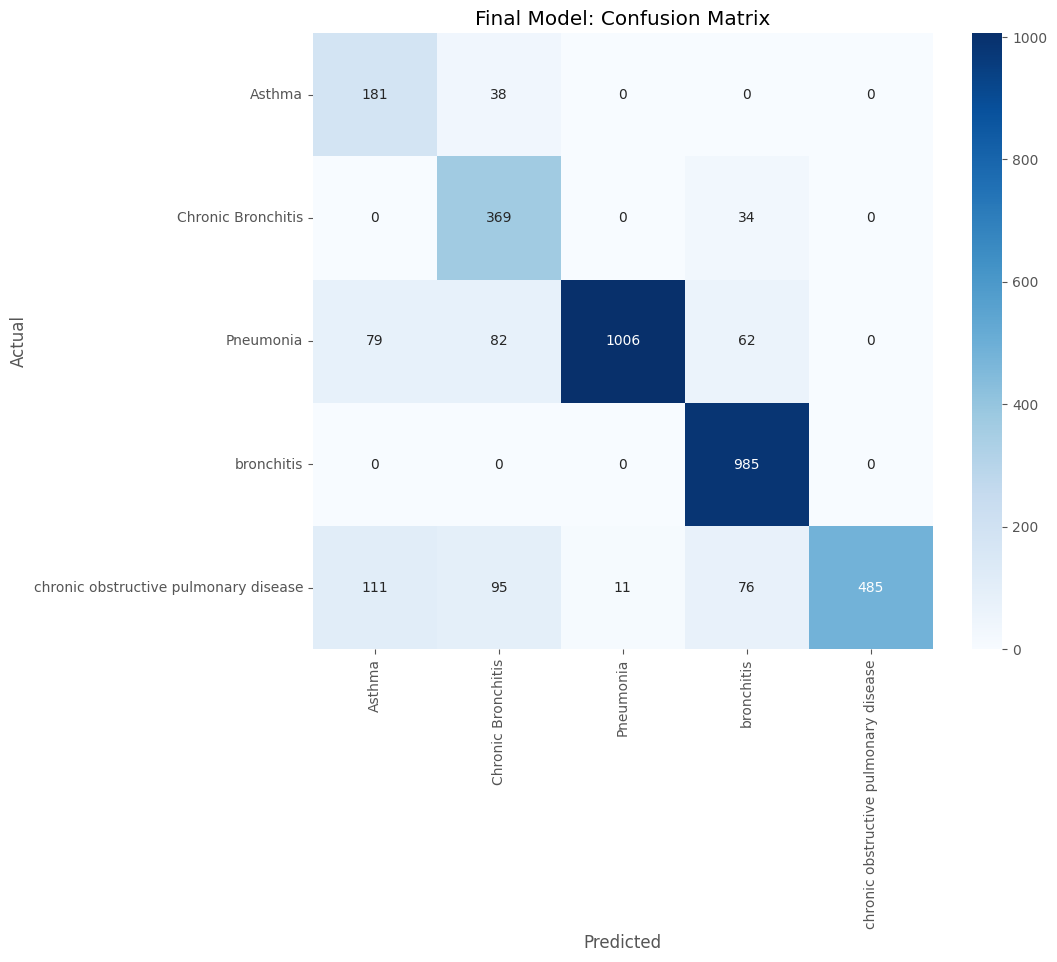

Production model saved as 'respiratory_disease_model.keras'


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

# 1. Get the best hyperparameters from the tuner
# Changed 'num_models' to 'num_trials' to fix the TypeError
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# 2. Build the model using the best parameters
def build_final_model(hp):
    model = Sequential()
    
    # Use Input layer to avoid the UserWarning
    model.add(Input(shape=(X_train_resampled.shape[1],)))
    
    # Dynamically build layers based on the best hyperparams found
    num_layers = hp.get('num_layers')
    for i in range(num_layers):
        model.add(Dense(
            units=hp.get(f'units{i}'),
            activation=hp.get(f'activation{i}')
        ))
        # Use a default if the dropout key for a specific layer index wasn't created
        dropout_rate = hp.get(f'Dropout{i}') if hp.values.get(f'Dropout{i}') is not None else 0.2
        model.add(Dropout(dropout_rate))
    
    # Output layer for 5 classes
    model.add(Dense(5, activation='softmax'))
    
    model.compile(
        optimizer=hp.get('optimizer'),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create the final model instance
final_model = build_final_model(best_hps)

# 3. Train the model
print("Starting Final Training with Best Hyperparameters...")
history = final_model.fit(
    X_train_resampled, 
    y_train_resampled, 
    epochs=50, 
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# 4. Evaluation
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 5. Classification Report
# Ensure 'le' (LabelEncoder) is defined from your previous steps
print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 6. Confusion Matrix Plot
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model: Confusion Matrix')
plt.show()

# 7. Save for production
final_model.save('respiratory_disease_model.keras')
print("Production model saved as 'respiratory_disease_model.keras'")